In [27]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

# --- 1. DATA IMPORT & PREPARATION ---
# Load MNIST dataset [cite: 165]
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to the interval [0, 1] [cite: 166]
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape to (Batch, 28, 28, 1) to represent the single grayscale channel [cite: 166]
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

# Convert labels to one-hot encoded format [cite: 166]
num_classes = 10
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes)



In [28]:
# --- 2. RESNET MODEL DEFINITION ---
def residual_block(x, filters):
    """A standard ResNet residual block with a skip connection."""
    shortcut = x
    # First convolution layer in the block
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    # Second convolution layer
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same', activation=None)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    # Add skip connection (the "Residual")
    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

def build_resnet(input_shape=(28, 28, 1), num_classes=10):
    model_input = tf.keras.layers.Input(shape=input_shape)
    
    # Feature Extraction Block [cite: 144]
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(model_input)
    x = residual_block(x, 32)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = residual_block(x, 64)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    
    # Classification Block [cite: 167, 173]
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    model_output = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
    return tf.keras.Model(inputs=model_input, outputs=model_output)

model = build_resnet()
model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_12[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 28, 28,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 28, 28,    │          0 │ add_4[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ activation_4[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 14, 14,    │     36,928 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 14, 14,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 14, 14,    │          0 │ add_5[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ activation_5[0][

 Total params: 514,762 (1.96 MB)

 Trainable params: 514,378 (1.96 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# --- 3. TRAINING ---
# Compile using categorical cross entropy and Adam optimizer [cite: 193, 194, 195]
model.compile(loss='categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

# Train the model [cite: 193, 198]
history = model.fit(train_images, train_labels, 
                    batch_size=128, 
                    epochs=10, 
                    validation_split=0.1)



Epoch 1/10
 27/422 ━━━━━━━━━━━━━━━━━━━━ 1:14 189ms/step - accuracy: 0.2948 - loss: 3.9505

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


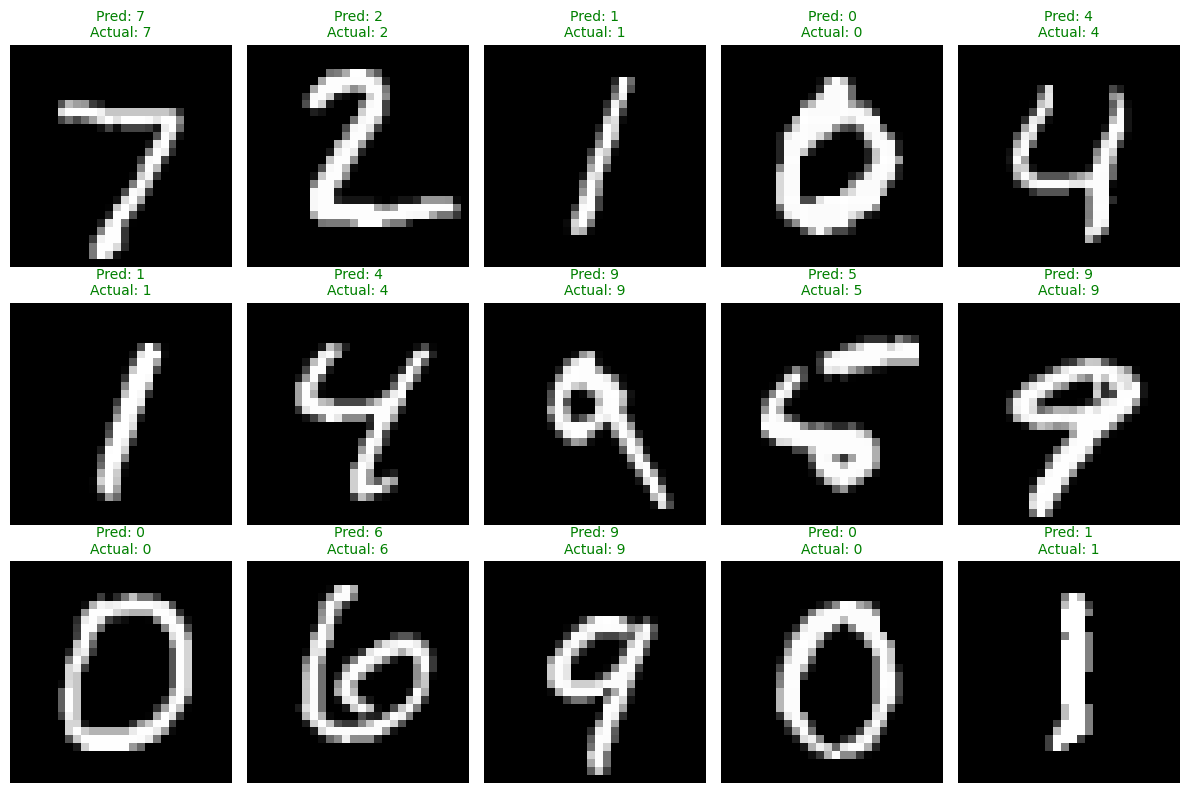


Overall Batch Test Accuracy: 98.92%


In [ ]:
# --- 4. BATCH TEST & VISUALIZATION ---
# 1. Get predictions for the entire test set [cite: 231]
batch_predictions = model.predict(test_images)
y_pred = np.argmax(batch_predictions, axis=1) # [cite: 232]
y_true = np.argmax(test_labels, axis=1)

# 2. Plot results from a random batch of 15 images
plt.figure(figsize=(12, 8))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray') # [cite: 234]
    
    color = 'green' if y_pred[i] == y_true[i] else 'red'
    plt.title(f"Pred: {y_pred[i]}\nActual: {y_true[i]}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 3. Final Overall Accuracy [cite: 196]
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"\nOverall Batch Test Accuracy: {test_acc*100:.2f}%")

In [ ]:
# Assuming your model variable is named 'model'
model.save('resnet_model.h5')

print("Model saved successfully as resnet_model.h5")

Model saved successfully as resnet_model.h5


In [7]:
import tensorflow as tf
import numpy as np

# 1. Load Model
model = tf.keras.models.load_model('resnet_model.h5')

# 2. Representative Dataset
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0

def representative_data_gen():
    for input_value in x_train[:100]:
        yield [input_value.reshape(1, 28, 28, 1)]

# 3. Setup Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# FIX: Use TFLITE_BUILTIN and ensure the supported types are set correctly
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8] 

# This forces the weights and activations to be 8-bit
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 4. Convert
tflite_model = converter.convert()
TFLITE_MODEL_PATH = 'resnet_model.tflite'
with open(TFLITE_MODEL_PATH, 'wb') as f:
    f.write(tflite_model)

print("Quantization Successful!")

INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmp4azw5hx6\assets


INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmp4azw5hx6\assets


Saved artifact at 'C:\Users\ng822\AppData\Local\Temp\tmp4azw5hx6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2749570995728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749571000336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749650386768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749571000912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749571002064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749571002256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749571001104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749571001488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749571001872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2749571002832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  27495

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantization Successful!


In [8]:
import os

def convert_tflite2cc(tflite_path, cc_path, model_name="resnet_model"):
    """Converts a TFLite file to a C++ file containing a byte array."""
    with open(tflite_path, 'rb') as f:
        tflite_content = f.read()
    
    hex_line = [f'0x{byte:02x}' for byte in tflite_content]
    
    with open(cc_path, 'w') as f:
        f.write(f'#include "{model_name}.h"\n\n')
        f.write(f'const unsigned char g_{model_name}_data[] = {{\n')
        # Write 12 hex values per line for readability
        for i in range(0, len(hex_line), 12):
            f.write('  ' + ', '.join(hex_line[i:i+12]) + ',\n')
        f.write(f'}};\n\n')
        f.write(f'const int g_{model_name}_data_len = {len(tflite_content)};\n')

# Generate the .cc file
convert_tflite2cc(TFLITE_MODEL_PATH, "resnet_model.cc")

In [9]:
def generate_h_file(h_path, model_name="resnet_model"):
    with open(h_path, 'w') as f:
        f.write(f'#ifndef {model_name.upper()}_DATA_H_\n')
        f.write(f'#define {model_name.upper()}_DATA_H_\n\n')
        f.write(f'extern const unsigned char g_{model_name}_data[];\n')
        f.write(f'extern const int g_{model_name}_data_len;\n\n')
        f.write(f'#endif // {model_name.upper()}_DATA_H_\n')

# Generate the .h file
generate_h_file("resnet_model.h")

In [11]:

interpreter = tf.lite.Interpreter(model_path="resnet_model.tflite")
interpreter.allocate_tensors()

print("=== Tensors ===")
for t in interpreter.get_tensor_details():
    print(
        f"name={t['name']}, "
        f"shape={t['shape']}, "
        f"dtype={t['dtype']}"
    )

print("\n=== Ops ===")
for op in interpreter._get_ops_details():
    print(op["op_name"])


=== Tensors ===
name=serving_default_input_layer_1:0, shape=[ 1 28 28  1], dtype=<class 'numpy.int8'>
name=arith.constant, shape=[1], dtype=<class 'numpy.int32'>
name=arith.constant1, shape=[1], dtype=<class 'numpy.int32'>
name=arith.constant2, shape=[], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst, shape=[10], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst1, shape=[ 10 128], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst2, shape=[128], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst3, shape=[ 128 3136], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst4, shape=[64], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst5, shape=[64  3  3 64], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst6, shape=[64], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst7, shape=[64], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst8, shape=[64], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst9, shape=[64  3  3 64], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst10, shape=[64], dtype

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
